---

Reawakening

---

In [1]:
# autoload
%load_ext autoreload
%autoreload 2

# import pgl commands
from pgl import pgl, pglExperiment, pglEyeTrackingCalibrationTask, pglMessageAckTask, pglImageDatabase, pglMessages, pglTask, pglLabJack, pglParameter

# import other libraries
import numpy as np

# initialize pgl
pgl = pgl()
pgl.cleanUp()

================================ pglBase: init =================================
(pgl) mglMetal error log can be viewed in MacOS Console app by searching for PROCESS mglMetal or in a terminal with:
      log stream --level info --process mglMetal
(pgl) To search for something specifc, e.g. messages from mglMovie:
      log stream --predicate 'eventMessage CONTAINS "mglMovie"' --style syslog --level info
(pgl:checkOS) Python version: 3.12.14 | packaged by conda-forge | (main, Aug 21 2026, 22:39:36) [Clang 19.1.7 ]
(pgl:checkOS) Running on MacBook Pro (MacBookPro18,3) with macOS version: 26.6.2
(pgl:checkOS) Apple M1 Pro Cores: 8 (6 Performance and 2 Efficiency) Memory: 32 GB
(pgl:checkOS) GPU: Apple M1 Pro (Built-In) 14 cores, Metal 4 support
(pgl:checkOS)   Color LCD [Main Display]: 3024 x 1964 Retina (Built-in Liquid Retina XDR Display) GammaTable size: 1024
(pgl:checkOS)   LED Cinema Display: 1600 x 1000 (Unknown type) GammaTable size: 1024
(pglBase) Main library instance created
(pg

---

Display settings

---

In [ ]:
# display settings - LCD should show up as SAMSUNG (select from top)
pgl.displaySettings()

---

Settings

---

In [ ]:
# Experiment settings, select reawakening
pgl.settings()

---

Eye tracker settings

---

In [ ]:
# set eye tracker settings, for example how many calibration points and the screen area to use for calibration
pgl.eyeTrackerSettings(settingsName='reawakening')

---

Search task

---

In [ ]:
class pglSearchTask(pglTask):
    
    ########################
    def __init__(self, pgl, nTrials=150, continueFromLastRun=True):
        super().__init__(pgl)
        
        # set task parameters, these will automatically be saved in the settings file
        self.settings.taskName = "Search Task"
        self.settings.nTrials = nTrials
        self.settings.continueImagesFromLastRun = continueFromLastRun
        
        # fixed parameters, these will automatically be saved in the settings file
        self.settings.config.imagesDirectory = "/Users/justin/Desktop/reawakening/stimulus/chair/0001"
        self.settings.config.imageHeight= 15
        
        # setup digitalIO
        self.settings.channel = 0
        #from pgl import pglLabJack
        self.digIO = None
        #self.digIO = pglLabJack()
        #self.digIO.setupDigitalOutput(channel=self.settings.channel)
        
        # set seglens, 
        # 1st segment is fixation
        # 2nd segment is image display
        # 2nd segment is ISI
        self.settings.seglen = [0.5, 2.5, 1.0]
        
        # response mappings for proper display
        self.data.responseMapping = {
            0: ("Present", "#0072B2"),
            1: ("Absent", "#6F8794"),
        }

        # initialize image database using parameters from config
        self.state._imdb = pglImageDatabase(self.settings.config.imagesDirectory)
        if self.state._imdb.nStimuli==0:
            pglMessages.warning(f"No images found in {self.state._imdb.dataPath}")
            return
        
        # preload images
        self.state._imdb.preload()            

    ########################
    def configure(self,e):
        '''
        configure the task by adding parameters from last run if it exists
        '''
        
        if self.settings.continueImagesFromLastRun:
            # get last run parameters
            parameters = e.getLastRunParameters(task=self)
        else:
            parameters = []
                
        print("#-"*40)        
        if parameters:
            # add the parameters from last run
            for p in parameters: 
                pglMessages.message("Countinuing images from last run")
                p.print()
                self.addParameter(p)                    
        else:
            pglMessages.message("Starting new from first image")
            # this must be the first run so initialize parameters
            imageNumParameter = pglParameter('imageNum',np.arange(self.state._imdb.nStimuli),randomize=True, randomSeed=42)
            self.addParameter(imageNumParameter)
        print("#-"*40)        
        
    ########################
    def startSegment(self, startTime):
        '''
        Start a segment
        '''
        super().startSegment(startTime)
    
        # load the image
        if self.state.currentSegment == 0: 
            # send digIO
            if self.digIO: self.digIO.digitalOutputPulse(self.settings.channel)
                
            # reset got response
            self.state.gotResponse = False
            # set fixation color to white
            self.state.fixColor = 1
            # get the current image number
            self.state.imageNum = self.currentParams['imageNum']
            # get the image data
            img = self.state._imdb.get(self.state.imageNum)
            img.convert("RGB")
            print(f"img: {img}")
            # turn into a pglImage
            self.state._currentImage = self.pgl.imageCreate(np.array(img))

    ########################
    # handleSubjectResponse
    ########################    
    def handleSubjectResponse(self, response, updateTime):
        '''
        Handle the subject response. Response will come in as an integer
        value of what button was pressed. The order of buttons is set
        in pgl.settings() in the field "responseKeys"
        '''
        # already received a response
        if self.state.gotResponse: return None
        # mark that we got a response
        self.state.gotResponse = True
        
        # return response type
        return response

    ########################
    # updateScren
    ########################
    def updateScreen(self):
        '''
        update the screen
        '''
        if self.state.currentSegment == 1: 
            if self.state._currentImage:
                self.state._currentImage.display(height=self.settings.config.imageHeight)
        else:
            pgl.fixationABC()


---

Setup experiment

---

In [53]:
# number of trials
nTrials = 150

# continue from last run. If set to True this will continue showing the next
# trail from wherever the last run ended. If False, then will start showing
# images fresh (randomization will be exactly the same though because
# random seed has been set)
continueFromLastRun = True

# clean up any open windows
pgl.cleanUp()

#e = pglExperiment(pgl,experimentName='Search Task',settingsName='reawakening')
e = pglExperiment(pgl,experimentName='Search Task',settingsName='window')

# First run a calibration
messageAckTask = pglMessageAckTask(pgl, "Press space to start eye calibration")
e.addTask(messageAckTask,addPhase=True)
calibrationTask = pglEyeTrackingCalibrationTask(pgl)
e.addTask(calibrationTask,addPhase=True)

# add the search task to the experiment
messageAckTask = pglMessageAckTask(pgl, "Press space to start search task")
e.addTask(messageAckTask,addPhase=True)
searchTask = pglSearchTask(pgl, nTrials=nTrials, continueFromLastRun=continueFromLastRun)
e.addTask(searchTask,addPhase=True)

# Run a final calibration
messageAckTask = pglMessageAckTask(pgl, "Press space to start eye calibration")
e.addTask(messageAckTask,addPhase=True)
calibrationTask = pglEyeTrackingCalibrationTask(pgl)
e.addTask(calibrationTask,addPhase=True)


(pglBase:removeOrphanedSockets) No orphaned sockets found in /Users/justin/Library/Containers/gru.mglMetal/Data
(pgl->pglSettingsManager:getSettings) Loading settings from '/Users/justin/.pgl/settings/window.json'.
(pglImageDatabase->pglStimulusDatabase:__init__) Found 100 stimulus files in /Users/justin/Desktop/reawakening/stimulus/chair/0001
(pglImageFile:_loadImage) Loading image: //Users/justin/Desktop/reawakening/stimulus/chair/0001/000.jpg
(pglImageFile:_loadImage) Loading image: //Users/justin/Desktop/reawakening/stimulus/chair/0001/001.jpg
(pglImageFile:_loadImage) Loading image: //Users/justin/Desktop/reawakening/stimulus/chair/0001/002.jpg
(pglImageFile:_loadImage) Loading image: //Users/justin/Desktop/reawakening/stimulus/chair/0001/003.jpg
(pglImageFile:_loadImage) Loading image: //Users/justin/Desktop/reawakening/stimulus/chair/0001/004.jpg
(pglImageFile:_loadImage) Loading image: //Users/justin/Desktop/reawakening/stimulus/chair/0001/005.jpg
(pglImageFile:_loadImage) Load

---

Run task

---

(pglBase:removeOrphanedSockets) No orphaned sockets found in /Users/justin/Library/Containers/gru.mglMetal/Data
================================= pglBase:open =================================
(pgl:_resolution:getResolution) Display 0/2: 1512x982 120Hz 32bits
(pglBase:getMetalAppName) Using latest build: /Users/justin/Library/Developer/Xcode/DerivedData/Build/Products/Release/mglMetal.app
(pgl->pglBase:open) Starting mglMetal application: /Users/justin/Library/Developer/Xcode/DerivedData/Build/Products/Release/mglMetal.app
(pgl->pglBase:open) Using socket with address: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260918_094700.TgjUXVPS9K
(pgl:_pglComm) .Connected to: /Users/justin/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260918_094700.TgjUXVPS9K
(pgl:_resolution:getResolution) Display 0/2: 1512x982 120Hz 32bits
(pglKeyboardMouse:start) Starting keyboard and mouse event listener.
(pglEventListener) Eating 5 keys: ['`', 'escape', 'f', 'h', 'space']
(

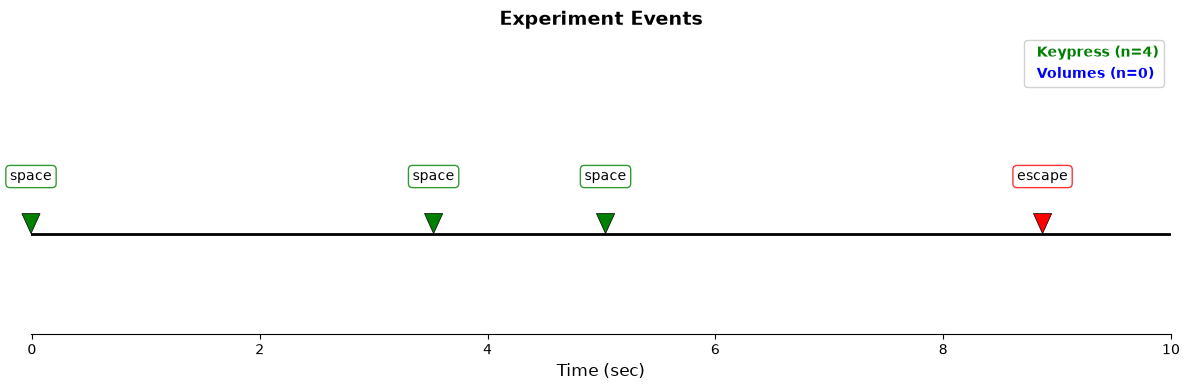

(pglTaskData:display) Insufficient trial events found to display.
(pglEyeTrackingCalibrationTask:display) No eye tracker initialized, cannot display eye tracking calibration task
(pglTaskData:display) Insufficient trial events found to display.
(pglTaskData:display) Insufficient trial events found to display.
(pglTaskData:display) Insufficient trial events found to display.
(pglEyeTrackingCalibrationTask:display) No eye tracker initialized, cannot display eye tracking calibration task


In [54]:
e.initScreen()
e.run()
e.display()


---

Test Labjack

---

In [ ]:
from pgl import pgl, pglLabJack
pgl = pgl()
labJack = pglLabJack()

In [ ]:
labJack.setupDigitalOutput(channel=0, group="FI0", pulseLen=3)

In [ ]:
labJack.digitalOutputPulse(0)

Self-initatied trial
Do not require fixation
Cross on the gray screen - press space bar - initiates stimulus 35x35 if you think there is a target press j if you do not think there is the target press j. As soon as you press the key it goes to the gray screen with a fixation cross.\
Every 25th
Calibration task
5 minutes for 100 images (3 seconds per image)
10 minutes for 100 images (6 seconds per image)

Instead to fixed interval for fixation 0.5s then 2s per image (Eckstein timing) 1s 


In [19]:
p = e.getLastRunParameters(task=e.tasks[3])

(pglRun:data) Loading data for: //Users/justin/data/searchTask/s0000/session_2026-09-18/run_09-33-24
(pglRun:data) Loading data for: //Users/justin/data/searchTask/s0000/session_2026-09-18/run_09-31-02
(pglRun:data) Loading data for: //Users/justin/data/searchTask/s0000/session_2026-09-18/run_09-32-09
(pglRun:experimentSettings) Loading experiment settings for: //Users/justin/data/searchTask/s0000/session_2026-09-18/run_09-33-24
(pglRun:getTaskAt) Loading task 3: task04_searchTask for //Users/justin/data/searchTask/s0000/session_2026-09-18/run_09-33-24
(pglTask:load) Loading task data from: /Users/justin/data/searchTask/s0000/session_2026-09-18/run_09-33-24/task04_searchTask
(pglParameter:load) Loaded parameter imageNum from: /Users/justin/data/searchTask/s0000/session_2026-09-18/run_09-33-24/task04_searchTask/parameters/imageNum


In [ ]:
p[0]

pglParameter(name=imageNum, validValues=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99], description=)